# Feature engineering

Ce notebook transforme les variables brutes du jeu de données Titanic en
caractéristiques potentiellement plus informatives pour les modèles de machine
learning.

Les transformations réalisées ici sont déterministes : elles ne calculent aucune
statistique à partir de la variable cible et n'apprennent aucun paramètre sur les
données. Elles peuvent donc être appliquées de manière identique aux jeux
d'entraînement et de test.

Les opérations dépendant des données, telles que l'imputation, la standardisation et
l'encodage des catégories, seront réalisées ultérieurement dans un pipeline
Scikit-learn.

---

## Importations et configuration

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42

CURRENT_DIR = Path.cwd()

if (CURRENT_DIR / "data").exists():
    PROJECT_ROOT = CURRENT_DIR
elif (CURRENT_DIR.parent / "data").exists():
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    raise FileNotFoundError(
        "Impossible de localiser la racine du projet."
    )

DATA_DIR = PROJECT_ROOT / "data" / "raw"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
SRC_DIR = PROJECT_ROOT / "src"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
    
print(f"Racine du projet : {PROJECT_ROOT}")

Racine du projet : c:\Users\hoare\Programming\project\titanic-project


---

## Chargement des données brutes

Les fichiers bruts sont rechargés depuis le dossier `data/raw`. Le jeu
d'entraînement contient la cible `Survived`, alors que le jeu de test ne la contient
pas.

In [2]:
train_path = DATA_DIR / "train.csv"
test_path = DATA_DIR / "test.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print(f"Train : {train_df.shape}")
print(f"Test  : {test_df.shape}")

train_df.head()

Train : (891, 12)
Test  : (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Vérification des données

In [3]:
assert "Survived" in train_df.columns
assert "Survived" not in test_df.columns

assert train_df["PassengerId"].is_unique
assert test_df["PassengerId"].is_unique

print("Structure des données validée.")

Structure des données validée.


---

## Séparation de la cible

La fonction de création des variables ne doit jamais accéder à la variable cible.
Nous séparons donc `Survived` des caractéristiques brutes avant d'effectuer le feature
engineering.

In [4]:
TARGET = "Survived"

X_train_raw = train_df.drop(columns=TARGET).copy()
y_train = train_df[TARGET].copy()

X_test_raw = test_df.copy()

test_passenger_ids = test_df["PassengerId"].copy()

print(f"X_train_raw : {X_train_raw.shape}")
print(f"y_train : {y_train.shape}")
print(f"X_test_raw : {X_test_raw.shape}")

X_train_raw : (891, 11)
y_train : (891,)
X_test_raw : (418, 11)


### Vérification

In [5]:
assert TARGET not in X_train_raw.columns
assert TARGET not in X_test_raw.columns

assert len(X_train_raw) == len(y_train)

print("La cible est correctement séparée.")

La cible est correctement séparée.


---

## Construction de nouvelles variables

Les analyses exploratoires suggèrent plusieurs transformations :

- `FamilySize` représente le nombre total de membres de la famille à bord, passager
  inclus ;
- `IsAlone` indique si le passager voyage seul ;
- `FamilyGroup` regroupe les tailles de famille en catégories plus stables ;
- `Title` extrait le titre contenu dans le nom du passager ;
- `Deck` extrait le pont à partir du numéro de cabine ;
- `CabinKnown` indique si l'information sur la cabine est disponible ;
- `TicketPrefix` extrait le préfixe non numérique du billet ;
- `NameLength` représente la longueur du nom complet.

Ces variables sont créées sans utiliser la cible.

---

## Taille de la famille

La formuel est :
$$ \text{FamilySize} = \text{SibSp} + \text{Parch} + 1$$
- `SibSp` : conjoint, frères et soeurs à bord ;
- `Parch` : parents et enfant à bord ;
- `+1` : le passager lui-même.

In [6]:
family_demo = X_train_raw[
    ["PassengerId", "SibSp", "Parch"]
].copy()

family_demo["FamilySize"] = (
    family_demo["SibSp"]
    + family_demo["Parch"]
    + 1
)

family_demo["IsAlone"] = (
    family_demo["FamilySize"] == 1
).astype(int)

family_demo.head(10)

,PassengerId,SibSp,Parch,FamilySize,IsAlone
0,1,1,0,2,0
1,2,1,0,2,0
2,3,0,0,1,1
3,4,1,0,2,0
4,5,0,0,1,1
5,6,0,0,1,1
6,7,0,0,1,1
7,8,3,1,5,0
8,9,0,2,3,0
9,10,1,0,2,0


In [7]:
family_demo["FamilySize"].describe()

count    891.000000
mean       1.904602
std        1.613459
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max       11.000000
Name: FamilySize, dtype: float64

In [8]:
family_demo["IsAlone"].value_counts()

IsAlone
1    537
0    354
Name: count, dtype: int64

`FamilySize` conserve la taille exacte de la famille, tandis que `IsAlone` représente
une version binaire de cette information. Une valeur de `1` pour `IsAlone` signifie que
le passager voyage seul.

---

## Regroupement des familles
Les tailles de famille élevées correspondent à peu d'observations. On pourra créer des catégories fixes tel que :
- `1` : seul
- `2 à 4` : petite famille
- `5 à 7` : famille moyenne
- `8 et plus` : grande famille.

In [9]:
family_demo["FamilyGroup"] = np.select(
    condlist=[
        family_demo["FamilySize"].eq(1),
        family_demo["FamilySize"].between(2, 4),
        family_demo["FamilySize"].between(5, 7),
        family_demo["FamilySize"].ge(8)
    ],
    choicelist=[
        "Alone",
        "Small",
        "Medium",
        "Large"
    ],
    default="Unknown"
)

family_demo[
    ["SibSp", "Parch", "FamilySize", "IsAlone", "FamilyGroup"]
].head(10)

,SibSp,Parch,FamilySize,IsAlone,FamilyGroup
0,1,0,2,0,Small
1,1,0,2,0,Small
2,0,0,1,1,Alone
3,1,0,2,0,Small
4,0,0,1,1,Alone
5,0,0,1,1,Alone
6,0,0,1,1,Alone
7,3,1,5,0,Medium
8,0,2,3,0,Small
9,1,0,2,0,Small


In [10]:
family_demo["FamilyGroup"].value_counts()

FamilyGroup
Alone     537
Small     292
Medium     49
Large      13
Name: count, dtype: int64

$\to$ Les seuils sont définis manuellement à partir de l'EDA. Ils ne sont pas caculés à partir de la cible

---

## Extraction du titre
Les noms du Titanic suivent généralement le format suivant :

```text
Braund, Mr. Owen Harris
Cumings, Mrs. John Bradley
Heikkinen, Miss. Laina
```
Donc le titre se situe entre la virgule et le point.

In [11]:
title_demo = X_train_raw[
    ["PassengerId", "Name", "Sex", "Age"]
].copy()

title_demo["Title"] = (
    title_demo["Name"]
    .str.extract(r",\s*([^.]*)\.", expand=False)
    .str.strip()
)

title_demo[
    ["Name", "Title"]
].head(10)

,Name,Title
0,"Braund, Mr. Owen Harris",Mr
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs
2,"Heikkinen, Miss. Laina",Miss
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs
4,"Allen, Mr. William Henry",Mr
5,"Moran, Mr. James",Mr
6,"McCarthy, Mr. Timothy J",Mr
7,"Palsson, Master. Gosta Leonard",Master
8,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",Mrs
9,"Nasser, Mrs. Nicholas (Adele Achem)",Mrs


### Fréquences des titres

In [12]:
title_demo["Title"].value_counts()

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Major             2
Mlle              2
Col               2
Don               1
Mme               1
Ms                1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

Comme certain titre sont très rare. On va :
- remplacer `Mlle` et `Ms` par `Miss`
- remplacer `Mme` par `Mrs`
- conserver `Mr`, `Miss`, `Mrs` et `Master`
- regrouper les autres titres sous `Rare`

In [13]:
title_replacements = {
    "Mlle": "Miss",
    "Ms": "Miss",
    "Mme": "Mrs"
}

title_demo["Title"] = title_demo["Title"].replace(
    title_replacements
)

common_titles = ["Mr", "Miss", "Mrs", "Master"]

title_demo["TitleGrouped"] = title_demo["Title"].where(
    title_demo["Title"].isin(common_titles),
    "Rare"
)

title_demo["TitleGrouped"].value_counts()

TitleGrouped
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64

### Vérification du lien avec le sexe et l'âge

In [14]:
pd.crosstab(
    title_demo["TitleGrouped"],
    title_demo["Sex"]
)

Sex,female,male
TitleGrouped,,
Master,0,40
Miss,185,0
Mr,0,517
Mrs,126,0
Rare,3,20


In [15]:
title_demo.groupby("TitleGrouped")["Age"].agg(
    ["count", "mean", "median"]
).round(2)

,count,mean,median
TitleGrouped,,,
Master,36,4.57,3.5
Miss,149,21.85,21.0
Mr,398,32.37,30.0
Mrs,109,35.79,35.0
Rare,22,45.55,48.5


Le titre synthétise plusieurs informations contenues dans le nom. Il est notamment
associé au sexe, à l'âge, au statut marital et parfois au statut social.

Le regroupement des titres rares permet d'éviter de créer de nombreuses catégories
contenant très peu d'observations.

---

## Extraction du pont et disponibilité de la cabine

In [16]:
cabin_demo = X_train_raw[
    ["PassengerId", "Pclass", "Cabin"]
].copy()

cabin_demo["CabinKnown"] = (
    cabin_demo["Cabin"].notna()
).astype(int)

cabin_demo["Deck"] = (
    cabin_demo["Cabin"]
    .str.strip()
    .str[0]
    .str.upper()
    .fillna("U")
)

cabin_demo.head(10)

,PassengerId,Pclass,Cabin,CabinKnown,Deck
0,1,3,NaN,0,U
1,2,1,C85,1,C
2,3,3,NaN,0,U
3,4,1,C123,1,C
4,5,3,NaN,0,U
5,6,3,NaN,0,U
6,7,1,E46,1,E
7,8,3,NaN,0,U
8,9,3,NaN,0,U
9,10,2,NaN,0,U


où `U` signifie ici `Unknown`

In [17]:
cabin_demo["CabinKnown"].value_counts()

CabinKnown
0    687
1    204
Name: count, dtype: int64

In [18]:
cabin_demo["Deck"].value_counts()

Deck
U    687
C     59
B     47
D     33
E     32
A     15
F     13
G      4
T      1
Name: count, dtype: int64

On peut constater que certaines cabines contiennent plusieurs numéros :
```text
C23 C25 C27
```
Donc l'utilisation du premier caractère reste cohérente, car les cabines indiquées pour un même passager appartiennent généralement au même pont.

### Conclusion
La valeur `U` représente un pont inconnu. La distinction entre une cabine renseignée
et une cabine absente est conservée dans `CabinKnown`.

La variable brute `Cabin` ne sera pas utilisée directement par les modèles en raison
de son grand nombre de modalités et de sa forte proportion de valeurs manquantes.

---

## Extraction du préfixe du billet
Les billets peuvent ressembler à
```text
A/5 21171
PC 17599
STON/O2. 3101282
113803
```

Le numéro complet possède beaucoup de modalités. On peut donc extraire une partie non numérique.

In [19]:
ticket_demo = X_train_raw[
    ["PassengerId", "Ticket"]
].copy()

ticket_demo["TicketPrefix"] = (
    ticket_demo["Ticket"]
    .astype(str)
    .str.upper()
    .str.replace(r"\d+", "", regex=True)
    .str.replace(r"[\s./]+", "", regex=True)
    .replace("", "NONE")
)

ticket_demo.head(15)

,PassengerId,Ticket,TicketPrefix
0,1,A/5 21171,A
1,2,PC 17599,PC
2,3,STON/O2. 3101282,STONO
3,4,113803,NONE
4,5,373450,NONE
5,6,330877,NONE
6,7,17463,NONE
7,8,349909,NONE
8,9,347742,NONE
9,10,237736,NONE


### Distribution

In [20]:
ticket_demo["TicketPrefix"].value_counts().head(20)

TicketPrefix
NONE       661
PC          60
CA          41
A           28
STONO       18
SOTONOQ     15
SCPARIS     11
WC          10
SOC          6
C            5
FCC          5
LINE         4
PP           3
WEP          3
SOPP         3
SWPP         2
PPP          2
SCAH         2
SOTONO       2
SCA          1
Name: count, dtype: int64

### Nombre de modalités

In [21]:
print(
    "Nombre de préfixes distincts :",
    ticket_demo["TicketPrefix"].nunique()
)

Nombre de préfixes distincts : 29


### Conclusion
`TicketPrefix` extrait la partie non numérique du billet. La catégorie `NONE`
correspond aux billets ne comportant aucun préfixe.

Cette variable sera testée avec prudence, car certaines catégories sont rares. Le
`OneHotEncoder` du futur pipeline devra être capable de gérer les catégories inconnues
dans le jeu de test.

---

## Longueur du nom
On va pas donner directement le nom complet au modèle. Sa longueur peut néanmoins servir d'indicateur indirect du nombre de titres, de noms ou de parenthèses.

In [22]:
name_demo = X_train_raw[
    ["PassengerId", "Name"]
].copy()

name_demo["NameLength"] = (
    name_demo["Name"]
    .str.len()
)

name_demo.head()

,PassengerId,Name,NameLength
0,1,"Braund, Mr. Owen Harris",23
1,2,"Cumings, Mrs. John Bradley (Florence Briggs Th...",51
2,3,"Heikkinen, Miss. Laina",22
3,4,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",44
4,5,"Allen, Mr. William Henry",24


In [23]:
name_demo["NameLength"].describe()

count    891.000000
mean      26.965208
std        9.281607
min       12.000000
25%       20.000000
50%       25.000000
75%       30.000000
max       82.000000
Name: NameLength, dtype: float64

Cette variable est optionnelle. Donc on pourra tester sans supposer qu'elle améliore nécessairement les performances.

---

## Fonction de création des variables

Toutes les transformations sont regroupées dans une fonction unique afin de garantir
qu'elles soient appliquées de façon identique aux jeux d'entraînement, de validation
et de test.

Cette fonction ne réalise aucune imputation, standardisation ou estimation statistique.
Elle n'utilise pas non plus la variable cible.


In [24]:
REQUIRED_COLUMNS = {
    "PassengerId",
    "Pclass",
    "Name",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Ticket",
    "Fare",
    "Cabin",
    "Embarked"
}


def build_features(dataframe):
    """
    Crée des variables supplémentaires à partir des données brutes
    du Titanic.

    Parameters
    ----------
    dataframe : pandas.DataFrame
        Données brutes sans la variable cible Survived.

    Returns
    -------
    pandas.DataFrame
        Copie des données contenant les variables créées.

    Notes
    -----
    Cette fonction est déterministe et n'utilise pas la cible.
    Elle n'effectue aucune imputation, standardisation ou opération
    apprenant des paramètres à partir des données.
    """
    missing_columns = REQUIRED_COLUMNS.difference(dataframe.columns)

    if missing_columns:
        raise ValueError(
            "Colonnes nécessaires absentes : "
            f"{sorted(missing_columns)}"
        )

    features = dataframe.copy()

    # Taille totale de la famille, passager inclus
    features["FamilySize"] = (
        features["SibSp"]
        + features["Parch"]
        + 1
    )

    # Indique si le passager voyage seul
    features["IsAlone"] = (
        features["FamilySize"] == 1
    ).astype(int)

    # Groupe familial
    features["FamilyGroup"] = np.select(
        condlist=[
            features["FamilySize"].eq(1),
            features["FamilySize"].between(2, 4),
            features["FamilySize"].between(5, 7),
            features["FamilySize"].ge(8)
        ],
        choicelist=[
            "Alone",
            "Small",
            "Medium",
            "Large"
        ],
        default="Unknown"
    )

    # Extraction et regroupement du titre
    features["Title"] = (
        features["Name"]
        .str.extract(r",\s*([^.]*)\.", expand=False)
        .str.strip()
        .replace({
            "Mlle": "Miss",
            "Ms": "Miss",
            "Mme": "Mrs"
        })
    )

    common_titles = {"Mr", "Miss", "Mrs", "Master"}

    features["Title"] = features["Title"].where(
        features["Title"].isin(common_titles),
        "Rare"
    )

    # Disponibilité et pont de la cabine
    features["CabinKnown"] = (
        features["Cabin"].notna()
    ).astype(int)

    features["Deck"] = (
        features["Cabin"]
        .str.strip()
        .str[0]
        .str.upper()
        .fillna("U")
    )

    # Préfixe du billet
    features["TicketPrefix"] = (
        features["Ticket"]
        .astype(str)
        .str.upper()
        .str.replace(r"\d+", "", regex=True)
        .str.replace(r"[\s./]+", "", regex=True)
        .replace("", "NONE")
    )

    # Longueur du nom
    features["NameLength"] = (
        features["Name"]
        .str.len()
    )

    return features


---

## Application de la fonction au train et au test

In [25]:
X_train_features = build_features(X_train_raw)
X_test_features = build_features(X_test_raw)

print(f"Train avant transformation : {X_train_raw.shape}")
print(f"Train après transformation : {X_train_features.shape}")

print(f"\nTest avant transformation  : {X_test_raw.shape}")
print(f"Test après transformation  : {X_test_features.shape}")

Train avant transformation : (891, 11)
Train après transformation : (891, 19)

Test avant transformation  : (418, 11)
Test après transformation  : (418, 19)


In [26]:
created_features = [
    "FamilySize",
    "IsAlone",
    "FamilyGroup",
    "Title",
    "CabinKnown",
    "Deck",
    "TicketPrefix",
    "NameLength"
]

X_train_features[
    created_features
].head(10)

,FamilySize,IsAlone,FamilyGroup,Title,CabinKnown,Deck,TicketPrefix,NameLength
0,2,0,Small,Mr,0,U,A,23
1,2,0,Small,Mrs,1,C,PC,51
2,1,1,Alone,Miss,0,U,STONO,22
3,2,0,Small,Mrs,1,C,NONE,44
4,1,1,Alone,Mr,0,U,NONE,24
5,1,1,Alone,Mr,0,U,NONE,16
6,1,1,Alone,Mr,1,E,NONE,23
7,5,0,Medium,Master,0,U,NONE,30
8,3,0,Small,Mrs,0,U,NONE,49
9,2,0,Small,Mrs,0,U,NONE,35


---

## Vérification des données brutes
On va venir vérifier si les données brutes n'ont pas été modifiées car la fonction doit retourner seulement une copie.

In [27]:
assert all(
    column not in X_train_raw.columns
    for column in created_features
)

assert all(
    column not in X_test_raw.columns
    for column in created_features
)

print("Les DataFrames bruts n'ont pas été modifiés.")

Les DataFrames bruts n'ont pas été modifiés.


---

## Vérification de la cohérence des variables créées

### Taille familiale

In [28]:
assert X_train_features["FamilySize"].ge(1).all()
assert X_test_features["FamilySize"].ge(1).all()

assert (
    X_train_features["IsAlone"]
    == X_train_features["FamilySize"].eq(1).astype(int)
).all()

assert (
    X_test_features["IsAlone"]
    == X_test_features["FamilySize"].eq(1).astype(int)
).all()

print("Variables familiales valides.")

Variables familiales valides.


### Variables sans valeur manquante

In [29]:
engineered_columns_without_missing = [
    "FamilySize",
    "IsAlone",
    "FamilyGroup",
    "Title",
    "CabinKnown",
    "Deck",
    "TicketPrefix",
    "NameLength"
]

train_engineered_missing = (
    X_train_features[
        engineered_columns_without_missing
    ]
    .isna()
    .sum()
)

test_engineered_missing = (
    X_test_features[
        engineered_columns_without_missing
    ]
    .isna()
    .sum()
)

display(
    pd.DataFrame({
        "train_missing": train_engineered_missing,
        "test_missing": test_engineered_missing
    })
)

,train_missing,test_missing
FamilySize,0,0
IsAlone,0,0
FamilyGroup,0,0
Title,0,0
CabinKnown,0,0
Deck,0,0
TicketPrefix,0,0
NameLength,0,0


Vérification automatique

In [30]:
assert train_engineered_missing.sum() == 0
assert test_engineered_missing.sum() == 0

print("Aucune valeur manquante dans les variables créées.")

Aucune valeur manquante dans les variables créées.


### Valeurs binaires

In [31]:
for column in ["IsAlone", "CabinKnown"]:
    assert X_train_features[column].isin([0, 1]).all()
    assert X_test_features[column].isin([0, 1]).all()

print("Les variables binaires sont valides.")

Les variables binaires sont valides.


---

## Vérification de la compabilité entre le train et le test

In [32]:
train_feature_columns = X_train_features.columns.tolist()
test_feature_columns = X_test_features.columns.tolist()

assert train_feature_columns == test_feature_columns, (
    "Les colonnes du train et du test sont différentes."
)

print("Le train et le test possèdent les mêmes variables.")

Le train et le test possèdent les mêmes variables.


On va venir vérifier également les types

In [33]:
dtype_comparison = pd.DataFrame({
    "train_dtype": X_train_features.dtypes.astype(str),
    "test_dtype": X_test_features.dtypes.astype(str)
})

dtype_comparison["same_dtype"] = (
    dtype_comparison["train_dtype"]
    == dtype_comparison["test_dtype"]
)

dtype_comparison

,train_dtype,test_dtype,same_dtype
PassengerId,int64,int64,True
Pclass,int64,int64,True
Name,str,str,True
Sex,str,str,True
Age,float64,float64,True
SibSp,int64,int64,True
Parch,int64,int64,True
Ticket,str,str,True
Fare,float64,float64,True
Cabin,str,str,True


In [34]:
assert dtype_comparison["same_dtype"].all()

print("Les types des colonnes sont cohérents.")

Les types des colonnes sont cohérents.


---

## Comparaison des catégories du train et du test
Le test peut contenir des catégories absentes du train. Ce n'est pas nécessairement une erreur, mais il faut quand même le savoir

In [35]:
categorical_features_to_check = [
    "Sex",
    "Embarked",
    "FamilyGroup",
    "Title",
    "Deck",
    "TicketPrefix"
]

for column in categorical_features_to_check:
    train_categories = set(
        X_train_features[column].dropna().unique()
    )

    test_categories = set(
        X_test_features[column].dropna().unique()
    )

    unseen_in_test = test_categories - train_categories
    absent_from_test = train_categories - test_categories

    print(f"\n{column}")
    print(f"  Catégories train : {len(train_categories)}")
    print(f"  Catégories test  : {len(test_categories)}")
    print(
        "  Présentes uniquement dans le test :",
        sorted(unseen_in_test)
    )
    print(
        "  Présentes uniquement dans le train :",
        sorted(absent_from_test)
    )


Sex
  Catégories train : 2
  Catégories test  : 2
  Présentes uniquement dans le test : []
  Présentes uniquement dans le train : []

Embarked
  Catégories train : 3
  Catégories test  : 3
  Présentes uniquement dans le test : []
  Présentes uniquement dans le train : []

FamilyGroup
  Catégories train : 4
  Catégories test  : 4
  Présentes uniquement dans le test : []
  Présentes uniquement dans le train : []

Title
  Catégories train : 5
  Catégories test  : 5
  Présentes uniquement dans le test : []
  Présentes uniquement dans le train : []

Deck
  Catégories train : 9
  Catégories test  : 8
  Présentes uniquement dans le test : []
  Présentes uniquement dans le train : ['T']

TicketPrefix
  Catégories train : 29
  Catégories test  : 22
  Présentes uniquement dans le test : ['AQ', 'LP', 'STONOQ']
  Présentes uniquement dans le train : ['AS', 'CASOTON', 'FA', 'LINE', 'PPP', 'SCAHBASLE', 'SCOW', 'SOP', 'SP', 'SWPP']


On pourra donc utiliser dans la pipeline :
```python
OneHotEncoder(handle_unknown="ignore")
```
Ainsi, une catégorie présente dans le test mais absente du train ne provoquera pas d'erreur.

---

## Analyse des valeurs manquantes après feature engineering

In [36]:
def missing_values_table(dataframe):
    missing_count = dataframe.isna().sum()
    missing_rate = 100 * missing_count / len(dataframe)

    return (
        pd.DataFrame({
            "missing_count": missing_count,
            "missing_rate": missing_rate
        })
        .query("missing_count > 0")
        .sort_values("missing_rate", ascending=False)
        .round(2)
    )


print("Valeurs manquantes après feature engineering — train :")
display(missing_values_table(X_train_features))

print("Valeurs manquantes après feature engineering — test :")
display(missing_values_table(X_test_features))

Valeurs manquantes après feature engineering — train :


,missing_count,missing_rate
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


Valeurs manquantes après feature engineering — test :


,missing_count,missing_rate
Cabin,327,78.23
Age,86,20.57
Fare,1,0.24


Les variables manquantes n'ont pas été imputées dans ce notebook. L'imputation devra
être ajustée uniquement sur les données d'entraînement de chaque découpage ou de
chaque pli de validation croisée.

Elle sera donc intégrée dans le pipeline de modélisation plutôt qu'appliquée
directement aux DataFrames.

---

## Sélection des variables destinées aux modèles
Toute les colonnes du DataFrame ne doivent pas être données directement au modèle. C'est pourquoi on va venir exclure :
- `PassengerId` : idenfiant
- `Name` : remplacé par `Title` et `NameLenght`
- `Ticket` : remplacé par `TicketPrefix`
- `Cabin` : remplacé par `Deck` et `CabinKnown`

In [37]:
COLUMNS_TO_DROP = [
    "PassengerId",
    "Name",
    "Ticket",
    "Cabin"
]

MODEL_FEATURES = [
    column
    for column in X_train_features.columns
    if column not in COLUMNS_TO_DROP
]

MODEL_FEATURES

['Pclass',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Fare',
 'Embarked',
 'FamilySize',
 'IsAlone',
 'FamilyGroup',
 'Title',
 'CabinKnown',
 'Deck',
 'TicketPrefix',
 'NameLength']

On va venir créer les jeux de données destinés à la modélisation

In [38]:
X_train_model = X_train_features[MODEL_FEATURES].copy()
X_test_model = X_test_features[MODEL_FEATURES].copy()

print(f"X_train_model : {X_train_model.shape}")
print(f"X_test_model  : {X_test_model.shape}")

X_train_model : (891, 15)
X_test_model  : (418, 15)


In [39]:
assert X_train_model.columns.equals(
    X_test_model.columns
)

assert len(X_train_model) == len(y_train)
assert len(X_test_model) == len(test_passenger_ids)

print("Les données de modélisation sont cohérentes.")

Les données de modélisation sont cohérentes.


---

## Définition des variables numériques et catégorielles
Dans ce cas, même si `Pclass`, `IsAlone` et `CabinKnown` sont représentées par des nombres, elles seront traitées comme des catégories.

In [40]:
NUMERIC_FEATURES = [
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "FamilySize",
    "NameLength"
]

CATEGORICAL_FEATURES = [
    "Pclass",
    "Sex",
    "Embarked",
    "IsAlone",
    "FamilyGroup",
    "Title",
    "CabinKnown",
    "Deck",
    "TicketPrefix"
]

print(f"Variables numériques     : {len(NUMERIC_FEATURES)}")
print(f"Variables catégorielles  : {len(CATEGORICAL_FEATURES)}")

Variables numériques     : 6
Variables catégorielles  : 9


In [41]:
selected_features = set(
    NUMERIC_FEATURES + CATEGORICAL_FEATURES
)

assert selected_features == set(MODEL_FEATURES), (
    "Certaines variables sont manquantes ou apparaissent plusieurs fois."
)

assert set(NUMERIC_FEATURES).isdisjoint(
    CATEGORICAL_FEATURES
)

print("Toutes les variables sont correctement réparties.")

Toutes les variables sont correctement réparties.


`Pclass` est codée par des nombres, mais représente une catégorie ordonnée plutôt
qu'une mesure quantitative continue.

`IsAlone` et `CabinKnown` sont des indicateurs binaires. Ils seront placés dans le
préprocesseur catégoriel afin d'obtenir un traitement uniforme avec les autres
catégories. Ils pourraient aussi être conservés directement sous forme numérique ;
les deux approches sont valides.

---

## Visualisation synthétique des variables créers

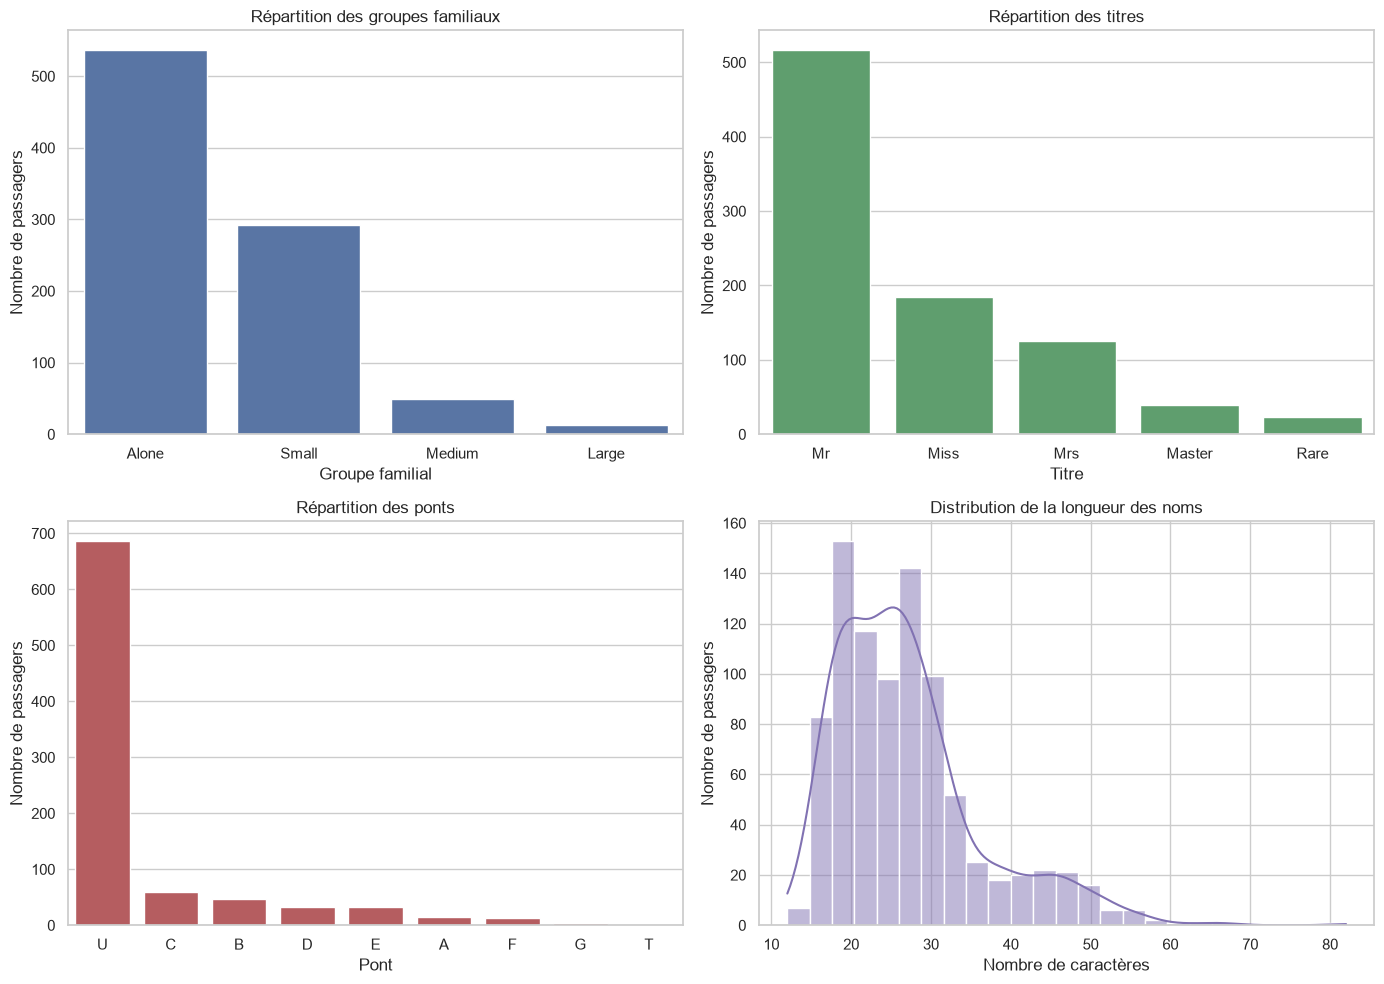

In [42]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(
    data=X_train_features,
    x="FamilyGroup",
    order=["Alone", "Small", "Medium", "Large"],
    color="#4C72B0",
    ax=axes[0, 0]
)

axes[0, 0].set(
    title="Répartition des groupes familiaux",
    xlabel="Groupe familial",
    ylabel="Nombre de passagers"
)

sns.countplot(
    data=X_train_features,
    x="Title",
    order=["Mr", "Miss", "Mrs", "Master", "Rare"],
    color="#55A868",
    ax=axes[0, 1]
)

axes[0, 1].set(
    title="Répartition des titres",
    xlabel="Titre",
    ylabel="Nombre de passagers"
)

deck_order = (
    X_train_features["Deck"]
    .value_counts()
    .index
)

sns.countplot(
    data=X_train_features,
    x="Deck",
    order=deck_order,
    color="#C44E52",
    ax=axes[1, 0]
)

axes[1, 0].set(
    title="Répartition des ponts",
    xlabel="Pont",
    ylabel="Nombre de passagers"
)

sns.histplot(
    data=X_train_features,
    x="NameLength",
    bins=25,
    kde=True,
    color="#8172B2",
    ax=axes[1, 1]
)

axes[1, 1].set(
    title="Distribution de la longueur des noms",
    xlabel="Nombre de caractères",
    ylabel="Nombre de passagers"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "engineered_features_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

---

## Concaténation temporaire de la cible pour vérifier les variables

In [43]:
feature_analysis_df = X_train_features.copy()
feature_analysis_df["Survived"] = y_train.values

In [44]:
def survival_summary(dataframe, group_column):
    summary = (
        dataframe
        .groupby(group_column, dropna=False)
        .agg(
            nombre_passagers=("Survived", "size"),
            nombre_survivants=("Survived", "sum"),
            taux_survie=("Survived", "mean")
        )
        .sort_values("taux_survie", ascending=False)
    )

    summary["taux_survie"] = (
        summary["taux_survie"]
        .mul(100)
        .round(2)
    )

    return summary


In [45]:
for feature in [
    "FamilyGroup",
    "Title",
    "CabinKnown",
    "Deck"
]:
    print(f"\n--- {feature} ---")
    display(
        survival_summary(
            feature_analysis_df,
            feature
        )
    )



--- FamilyGroup ---


,nombre_passagers,nombre_survivants,taux_survie
FamilyGroup,,,
Small,292,169,57.88
Alone,537,163,30.35
Medium,49,10,20.41
Large,13,0,0.00



--- Title ---


,nombre_passagers,nombre_survivants,taux_survie
Title,,,
Mrs,126,100,79.37
Miss,185,130,70.27
Master,40,23,57.50
Rare,23,8,34.78
Mr,517,81,15.67



--- CabinKnown ---


,nombre_passagers,nombre_survivants,taux_survie
CabinKnown,,,
1,204,136,66.67
0,687,206,29.99



--- Deck ---


,nombre_passagers,nombre_survivants,taux_survie
Deck,,,
D,33,25,75.76
E,32,24,75.00
B,47,35,74.47
F,13,8,61.54
C,59,35,59.32
G,4,2,50.00
A,15,7,46.67
U,687,206,29.99
T,1,0,0.00


---

## Test du module `src.features`

In [46]:
from src.features import (
    build_features,
    select_model_features,
    MODEL_FEATURES,
    NUMERIC_FEATURES,
    CATEGORICAL_FEATURES
)

On va venir recharger les données brutes

In [47]:
train_check = pd.read_csv(DATA_DIR / "train.csv")
test_check = pd.read_csv(DATA_DIR / "test.csv")

X_check = train_check.drop(columns="Survived")
y_check = train_check["Survived"]

X_check_engineered = build_features(X_check)
X_check_model = select_model_features(
    X_check_engineered
)

test_check_engineered = build_features(test_check)
test_check_model = select_model_features(
    test_check_engineered
)

print(f"Train final : {X_check_model.shape}")
print(f"Test final  : {test_check_model.shape}")

Train final : (891, 15)
Test final  : (418, 15)


In [48]:
assert list(X_check_model.columns) == MODEL_FEATURES
assert list(test_check_model.columns) == MODEL_FEATURES

assert X_check_model.columns.equals(
    test_check_model.columns
)

assert len(X_check_model) == len(y_check)
assert len(test_check_model) == len(test_check)

print("Le module src.features fonctionne correctement.")

Le module src.features fonctionne correctement.


---

# Conclusion

Le feature engineering a permis de transformer plusieurs variables brutes en
caractéristiques plus directement exploitables par les modèles.

## Variables créées

- `FamilySize` : taille totale de la famille à bord ;
- `IsAlone` : indique si le passager voyage seul ;
- `FamilyGroup` : catégorie décrivant la taille de la famille ;
- `Title` : titre extrait du nom et regroupé en modalités principales ;
- `CabinKnown` : indique si la cabine est renseignée ;
- `Deck` : pont extrait du numéro de cabine ;
- `TicketPrefix` : préfixe non numérique du billet ;
- `NameLength` : longueur du nom complet.

## Variables brutes exclues du futur modèle

- `PassengerId`, car il s'agit d'un identifiant ;
- `Name`, remplacé par `Title` et `NameLength` ;
- `Cabin`, remplacée par `Deck` et `CabinKnown` ;
- `Ticket`, remplacé par `TicketPrefix`.

## Prévention de la fuite de données

La fonction de feature engineering n'utilise pas `Survived` et n'apprend aucun
paramètre statistique. Elle peut donc être appliquée de manière identique aux données
d'entraînement, de validation et de test.

Les valeurs manquantes n'ont volontairement pas été imputées. L'imputation, la
standardisation et le one-hot encoding seront intégrés au pipeline Scikit-learn afin
que leurs paramètres soient appris uniquement sur les données d'entraînement.

## Prochaine étape

Le prochain notebook construira plusieurs pipelines complets :

1. une baseline avec `DummyClassifier` ;
2. une régression logistique ;
3. un arbre de décision ;
4. une forêt aléatoire ;
5. un modèle de gradient boosting.

Les modèles seront comparés avec une validation croisée stratifiée en utilisant
principalement l'accuracy, le F1-score et la ROC-AUC.